Study the space-weather dataset features correlations, and come up with new target variable corresponding to the visibility of auroras

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pvlib import solarposition

In [3]:
df = pd.read_csv("data/processed/data_aurora.csv")
df.head()

,datetime,latitude,longitude,city,Bz,solar_wind_speed,Kp,cloud_cover
0,2021-01-01 00:00:00,50.45,-104.63,Regina,1.6,365.0,0.0,4
1,2021-01-01 00:00:00,62.46,-114.32,Yellowknife,1.6,365.0,0.0,81
2,2021-01-01 01:00:00,50.45,-104.63,Regina,1.5,366.0,0.0,4
3,2021-01-01 01:00:00,62.46,-114.32,Yellowknife,1.5,366.0,0.0,99
4,2021-01-01 02:00:00,50.45,-104.63,Regina,-0.3,360.0,0.0,10


### Features definition :
**$Bz$** : The interplanetary magnetic field component. If $Bz$ is pointing southward (negative values), will allow solar storm particles to access the earth's magnetosphere, furthermore, interacting with the earth atmosphere, leading to high probability of aurora observation.

**solar_wind_speed** : Higher solar wind speed allows more interacting particles with the earth's magnetosphere, leading to more visible auroras.

**$Kp$** : an index that is globally recognized metric (0 to 9) measuring geomagnetic activity. A higher Kp-index indicates larger, brighter auroras that expand to lower geographic latitudes

**cloud_cover** : Higher concentration of clouds (>50%) will block viewing auroras.  Auroras altitude form 60 to 500 miles high, while clouds sit below 6 miles.

### Target feature Engineer :

Define the strength of aurora manifestation and visibility score

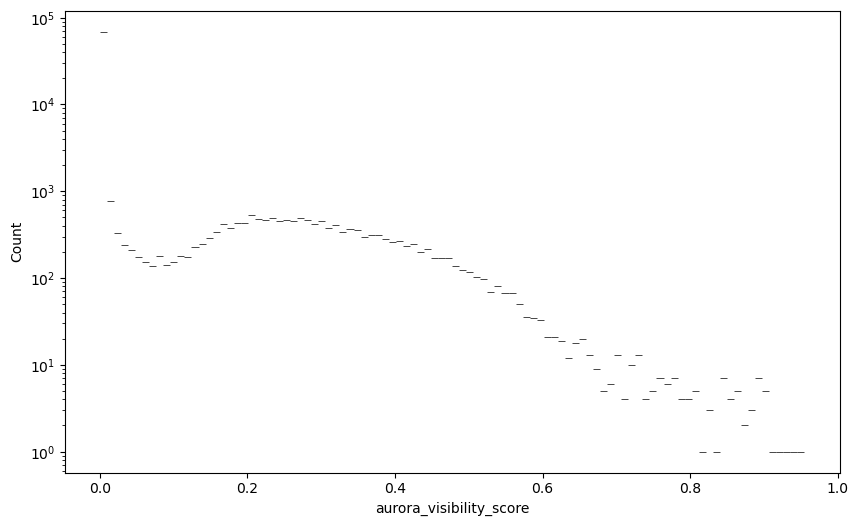

In [8]:
## Normalize the kp index between 0.0 and 1.0
kp_scale = np.clip(df["Kp"]/9.0, 0.0, 1.0)
# plt.hist(kp_scale)
# (kp_scale > 0.5).mean() * 100

## penalize the impact of positive Bz on aurora visibility.
# bz_factor = np.where(df["Bz"] >= 0.0, 0.1, 1.0)
# we use sigmoid function to represent: strongly negative Bz approaches 1.0, strongly positive approaches 0.05
# Smooth transition: strongly negative Bz approaches 1.0, strongly positive approaches 0.05
df["bz_factor"] = 0.05 + 0.95 / (1.0 + np.exp(0.3 * df["Bz"]))

## enhance the impact of solar wind speed > 300 km/s
# wind_boost = np.where(df["solar_wind_speed"] > 400, 1.0, 0.3)
df["solar_wind_factor"] = np.clip((df["solar_wind_speed"] - 300) / (500), 0.2, 1.0)

## total factor considering space conditions factors, for the aurora to occur
## We weight the features from the most impactfull, the sum(0.5+0.3+0.1) = 1.0
df["aurora_strength"] = (kp_scale * 0.5) + (df["bz_factor"] * 0.3) + (df["solar_wind_factor"] * 0.2)

## penalize events with higher percentage clouds
# clouds = np.where(df["cloud_cover"] > 50, 0.3, 1.0)
df["cloud_factor"] = 1.0 - (df["cloud_cover"] / 100.0) ** 2

## enhance aurora viewing during night times
# df["datetime"] = pd.to_datetime(df["datetime"])
# start_time = pd.to_datetime("22:00:00").time() # 10 pm
# finish_time = pd.to_datetime("03:00:00").time() # 2 am
# night_boost = np.where((df["datetime"].dt.time >= start_time) | (df["datetime"].dt.time <= finish_time), 1.0, 0.1)

## --- The night time depends on geographic location, seasonal shifts, and the Midnight Sun phenomenon. 
##-- We calculate the true solar elevation angle for our two locations. 
# 1. Ensure datetime is a proper DatetimeIndex and localized to UTC
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

if df.index.tz is None:
    df = df.tz_localize("UTC")

# 2. Initialize the column for solar elevation
df["solar_elevation"] = np.nan

# 3. Group by unique coordinate pairs to minimize expensive solar calculations
# This handles 2 cities, 50 cities, or thousands of moving GPS coordinates efficiently
coordinate_groups = df.groupby(["latitude", "longitude"], sort=False)

for (lat, lon), group_df in coordinate_groups:
    # Extract the precise timestamps for this specific location slice
    location_times = group_df.index
    
    # Calculate solar positions using pvlib
    solpos = solarposition.get_solarposition(
        time=location_times, 
        latitude=lat, 
        longitude=lon
    )
    
    # Vectorized assignment using multi-index/boolean mask matching the dataframe index
    # This prevents data drift or misalignment across rows
    df.loc[
        (df["latitude"] == lat) & (df["longitude"] == lon), 
        "solar_elevation"
    ] = solpos["apparent_elevation"]

# 4. Safely return 'datetime' back as a column without naming bugs
df = df.reset_index()
if "index" in df.columns:
    df = df.rename(columns={"index": "datetime"})

## now create a factor that enhances the optimal time to see aurora
## darkness gives full score (1), and daylight or twilight zeros it out (0.01)
df["darkness_factor"] = np.where(df["solar_elevation"] <= -12, 1.0, 0.01)

## compute the aurora visibility score
df["aurora_visibility_score"] = df["aurora_strength"] * df["cloud_factor"] * df["darkness_factor"]
df.describe()
# df["aurora_visibility_score"].hist()
plt.figure(figsize=(10, 6), dpi=100)
sns.histplot(data=df, x="aurora_visibility_score", bins=100, log_scale=(False, True)) #, log_scale=(False, True)
plt.show()


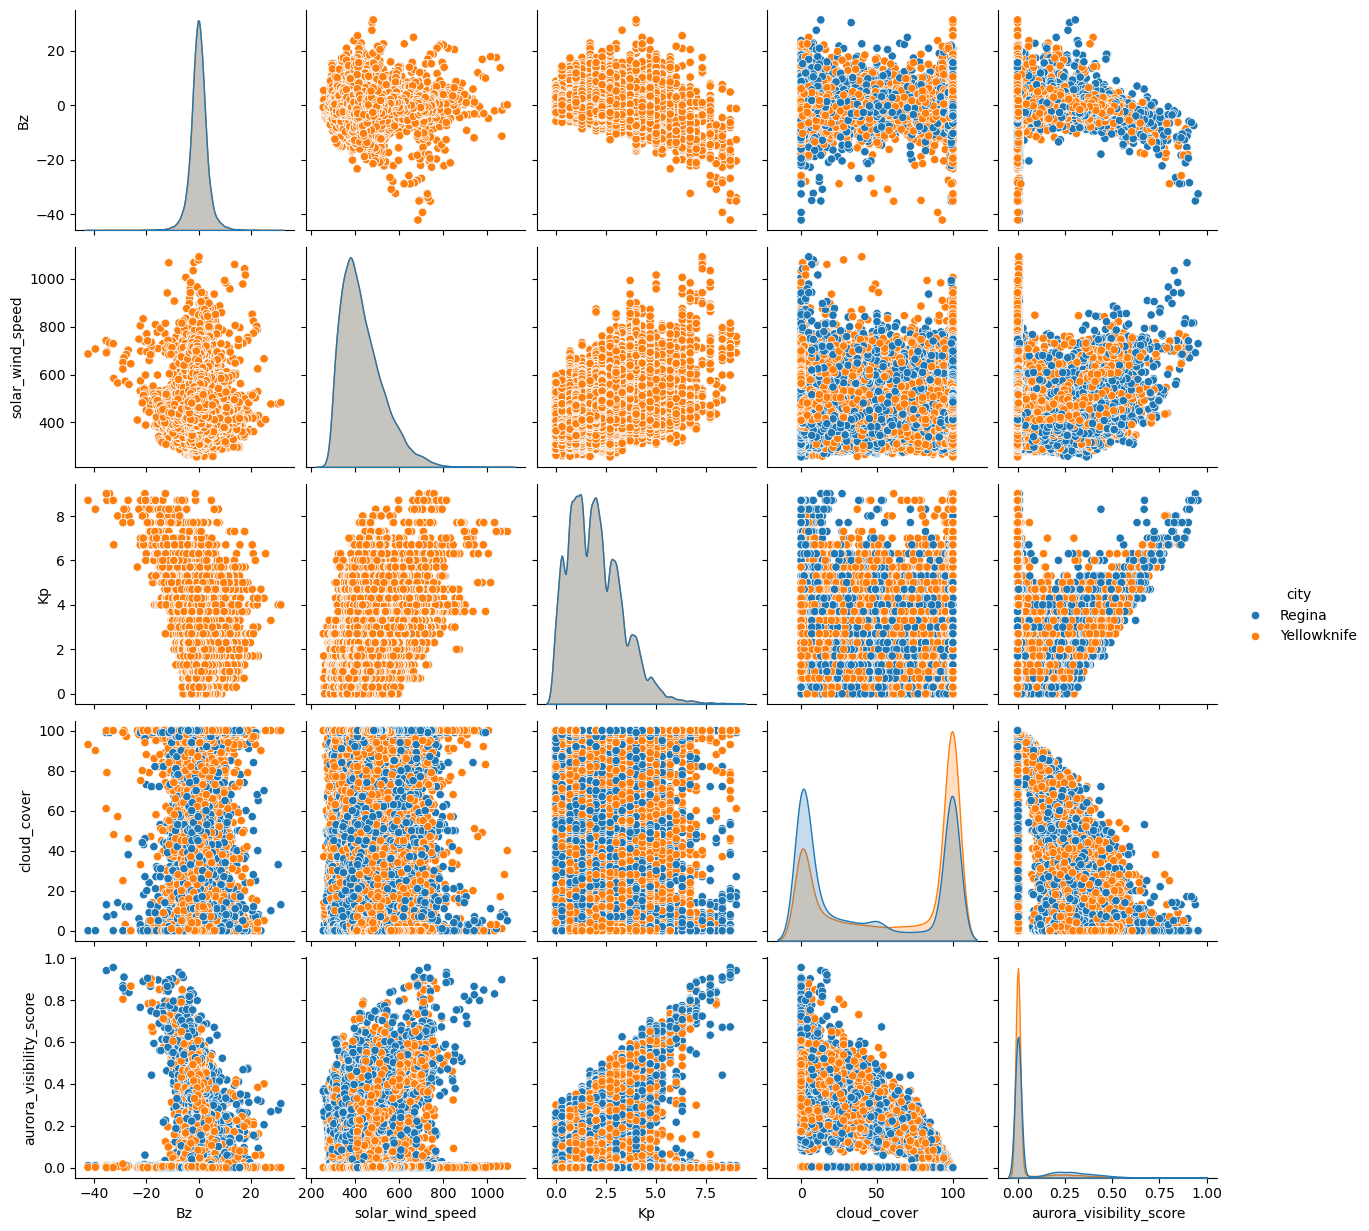

In [ ]:
### verify the corelations between the features
cols = ["Bz", "solar_wind_speed", "Kp", "cloud_cover", "aurora_visibility_score"]
sns.pairplot(data=df, x_vars=cols, y_vars=cols, hue="city")

In [ ]:
## Some events have small 'Kp' but high 'aurora_visibility_score' due, to strong negative 'Bz'
df.loc[(df["Kp"]>=7) & (df["aurora_visibility_score"]<=0.1), ['Bz', 'solar_wind_speed', 'cloud_cover', 'solar_elevation']].value_counts()

Bz     solar_wind_speed  cloud_cover  solar_elevation
-12.8  454.0             0             5.780226          1
                         96            6.073343          1
-18.3  444.0             0             14.849012         1
                         47            12.416066         1
-17.0  445.0             0             24.326640         1
                                                        ..
-10.6  685.0             100          -37.607566         1
 7.0   695.0             100          -31.747320         1
-3.2   942.0             100          -27.208709         1
 0.9   905.0             100          -33.682535         1
-3.6   897.0             100          -39.259547         1
Name: count, Length: 242, dtype: int64

In [19]:
df[["aurora_visibility_score"]].max().value_counts(normalize=True)

0.954917    1.0
Name: proportion, dtype: float64